# 1、实现RODM方法的内力计算

In [1]:
#import packages
import time
import numpy as np
import capytaine as cpt
import scipy
from capytaine.io.mesh_writers import write_STL
import matplotlib.pyplot as plt
from scipy.linalg import block_diag
from scipy.linalg import eigh
import vtk
import logging
import xarray as xr
from capytaine.io.xarray import merge_complex_values
from capytaine.post_pro import rao
logging.basicConfig(level=logging.INFO, format='%(levelname)-8s: %(message)s')
# user defined functions
import DM_ShowNodes as DMshow
import DM_Reading as dm_r
import DM_Assemble as DM_A
import SEREP as SEREP
import DM_Method as DM_M

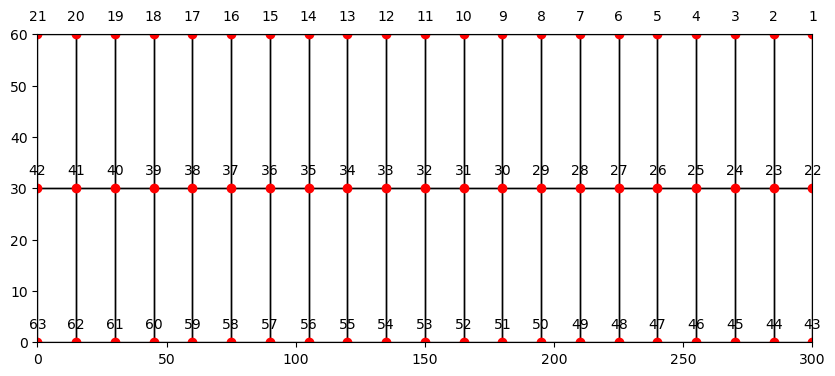

In [2]:
# Show nodes and node message from inp file
file_path = "E:\phd\Code\DM-FEM2D\Fem_inp\Job-1_largemesh.inp"
label_interval = 1
node = DMshow.plot_fea_model(file_path, label_interval)
#node_ids = [41, 39, 37, 35, 33, 31, 29, 27, 25, 23]

In [3]:
# Example call to the function
num_nodes = 793
node_position_params = (424, 6, 10)
hydrodynamic_data_path = "E:\phd\Code\DM-FEM2D\HydrodynamicData\Yoga\DM10_145_direction180.nc"
structure_data_paths = {
    'mass': 'E:\phd\Code\DM-FEM2D\StructureData\JobMesh5_5_MASS1.mtx',
    'stiffness': 'E:\phd\Code\DM-FEM2D\StructureData\JobMesh5_5_STIF1.mtx'}

In [8]:
result_reduce = DM_M.perform_RODM_reduce_order_model(num_nodes, node_position_params, hydrodynamic_data_path, structure_data_paths,use_hydrostatic=True)
# result_expaned = DM_M.perform_expansion_and_solve(num_nodes, node_position_params, hydrodynamic_data_path, structure_data_paths,use_hydrostatic=False)
result_yuan = DM_M.calculate_initial_displacement(num_nodes, node_position_params, hydrodynamic_data_path, structure_data_paths)

In [9]:
# Import force analysis model
from DM_forec_analysis import ForceAnalysis

def calculate_module_boundary_forces_793(global_displacement):
    # Create an instance of the ForceAnalysis class
    # Parameters include:
    # N: Total Number of nodes
    # H: Row
    # module_nodes: Number of nodes per module
    # module_number: Number of modules
    # element_length: Length of the element
    # element_width: Width of the element
    analyzer = ForceAnalysis(N=793, H=13, module_nodes=7, module_number=10, element_length=5, element_width=5, dof=5)
    # analyzer = ForceAnalysis(N=63, H=3, module_nodes=3, module_number=10, element_length=15, element_width=30,dof=5)
    # Compute module displacements using the provided displacement matrix X
    module_displacements = analyzer.compute_module_displacements(displacement_matrix=global_displacement)

    # Fetch the stiffness matrix for an element from a specified file
    K_element = dm_r.get_stiffness_matrix("E:\phd\Code\DM-FEM2D\StructureData\sub_m10_w60.mtx")#E:\phd\Code\DM-FEM2D\data\model300_60\Job-1_sub-1_STIF1.mtx
    K_element = SEREP.reduce_dofs(K_element, 91, [5])
    # K_element = SEREP.reduce_dofs(K_element, 9, [5])

    # Compute forces within the module using the stiffness matrix and module displacements
    module_forces = analyzer.compute_module_forces(K_element, module_displacements)

    # Map the forces from module level to global nodes
    global_forces = analyzer.map_forces_to_global_nodes(module_forces)
    # Compute the boundary forces for each module
    module_boundary = analyzer.get_middle_interface_forces(global_forces)
    # Visualize global forces using a plot
    analyzer.plot_forces(global_forces)

    return module_boundary

In [ ]:
# Calculate the boundary forces
boundary_forces_expanded = calculate_module_boundary_forces_793(result_expaned)
# boundary_forces_reduced = calculate_module_boundary_forces_793(result_reduce)

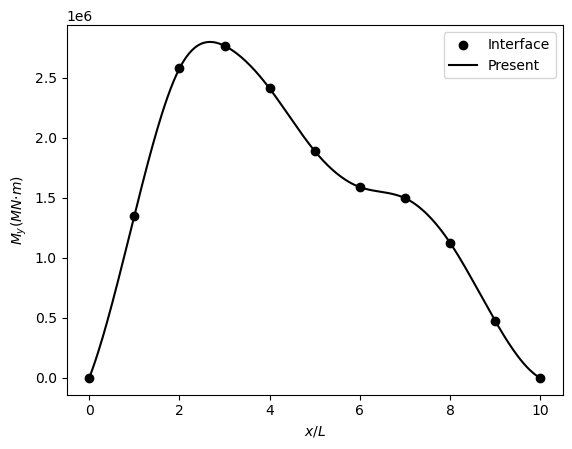

(0.0, 3.0)

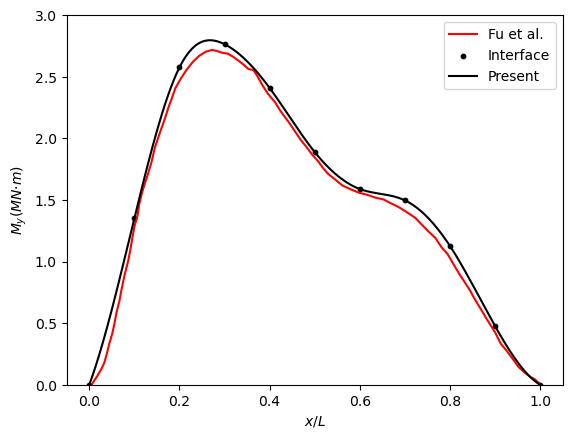

In [11]:
result_yuan = SEREP.reduce_force_matrix_dofs(result_yuan,793,5)
boundary_forces_reduced = calculate_module_boundary_forces_793(result_yuan)

# 绘制内力图
from DM_Verify import process_exp_data
exp_x, exp_y = process_exp_data(r"E:\phd\Code\DM-FEM2D\data\Experiment_300_60\fig9_bm_fu.txt")
exp_y = np.array(exp_y)
data = boundary_forces_reduced
x = np.arange(len(data))
y = data[:, 0]
from scipy import interpolate
spline = interpolate.CubicSpline(x, y)
x_new = np.linspace(0, len(data)-1, 300)
y_new = spline(x_new)
plt.plot(exp_x,exp_y/60,color = 'red', label = 'Fu et al.')
plt.scatter(x/10, y/1e6, color='black', s=10,label='Interface')
plt.plot(x_new/10, y_new/1e6,color ='black', label='Present')
plt.legend()
# plt.title("Scatter Plot and Cubic Spline Interpolation")
plt.xlabel(r"$x$/$L$")
plt.ylabel(r"$M_y$($MN{\cdot}m$)")
plt.ylim(0,3)

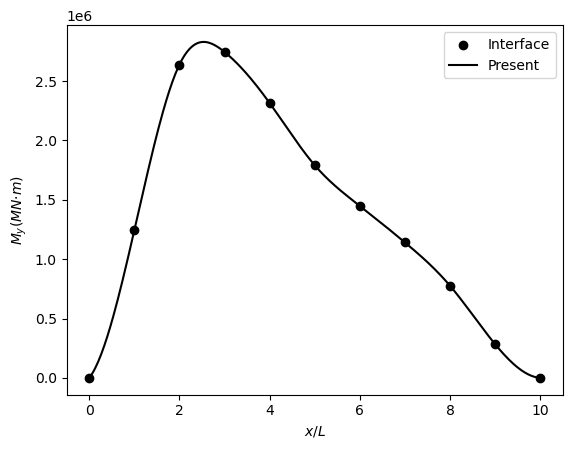

(0.0, 3.0)

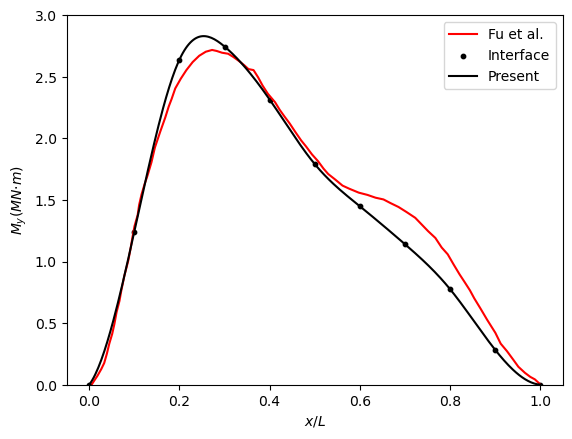

In [12]:
# result_reduce = result_reduce.reshape(793,5)[::-1]
boundary_forces_reduced = calculate_module_boundary_forces_793(result_reduce)

# 绘制内力图
from DM_Verify import process_exp_data
exp_x, exp_y = process_exp_data(r"E:\phd\Code\DM-FEM2D\data\Experiment_300_60\fig9_bm_fu.txt")
exp_y = np.array(exp_y)
data = boundary_forces_reduced
x = np.arange(len(data))
y = data[:, 0]
from scipy import interpolate
spline = interpolate.CubicSpline(x, y)
x_new = np.linspace(0, len(data)-1, 300)
y_new = spline(x_new)
plt.plot(exp_x,exp_y/60,color = 'red', label = 'Fu et al.')
plt.scatter(x/10, y/1e6, color='black', s=10,label='Interface')
plt.plot(x_new/10, y_new/1e6,color ='black', label='Present')
plt.legend()
# plt.title("Scatter Plot and Cubic Spline Interpolation")
plt.xlabel(r"$x$/$L$")
plt.ylabel(r"$M_y$($MN{\cdot}m$)")
plt.ylim(0,3)

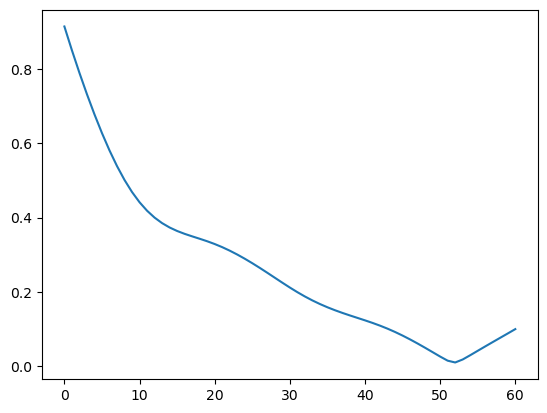

In [7]:
i = 2 # dof index
mid_reduce = result_reduce[366*5:427*5]  # Adjusted to Python's 0-based indexing
heave_reduce = abs(mid_reduce[i::5])
plt.plot(heave_reduce)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from DM_Verify import process_exp_data
i = 0 # dof index
# Assuming 'result_reduce' and 'result_yuan' contain global displacement results from the respective functions
# Calculate 'heave' from the reduced order model results
mid_reduce = result_reduce[366*5:427*5]  # Adjusted to Python's 0-based indexing
heave_reduce = abs(mid_reduce[i::5])

# Calculate 'heave' from the full order model results
mid_yuan = result_yuan[366*6:427*6]  # Adjusted to Python's 0-based indexing
heave_yuan = abs(mid_yuan[i::6])

mid_expaned = result_expaned[366*5:427*5]  # Adjusted to Python's 0-based indexing
heave_expaned = abs(mid_expaned[i::5])

# Load experimental data for comparison
x_exp, y_exp = process_exp_data("E:\\phd\\Code\\DM-FEM2D\\data\\Experiment_300_60\\exp_60.txt")
y_exp = np.array(y_exp)

import scienceplots
plt.style.use(['science','no-latex','ieee'])


# Create a plot with both simulation results and experimental data
x1 = np.linspace(0, 1, len(heave_reduce))  # Adjust x1 to match the length of the simulation results if needed
plt.plot(x1, heave_reduce, label="Reduced Order Model", linewidth=2)
plt.plot(x1, heave_yuan[::-1], label="Oriagnal", linewidth=2)
plt.plot(x1, heave_expaned, label="Expanded Order Model", linewidth=2)
# plt.scatter(x_exp, y_exp, color='red', label="Experimental Data", s=10)

# # Adding plot details
plt.legend()
# plt.ylim(0, 1)  # Adjust y-axis limits if necessary
plt.xlabel(r'$x/L$')
plt.ylabel(r'Heave RAO ($m$/$m$)')

# # Show the plot
# plt.show()

In [ ]:
# Calculate 'heave' from the reduced order model results
i = 2
mid_reduce = result_reduce[366*5:427*5]  # Adjusted to Python's 0-based indexing
heave_reduce = abs(mid_reduce[i::5])
plt.plot(heave_reduce)
np.savetxt("heave_reduce.txt", heave_reduce)

In [ ]:
plt.imshow(np.abs(result_expaned[4::5].reshape(13,61)))

### 1、对比BEM hydrostatic vs fem spring

In [ ]:
# 对比降解模型
result_reduce_bem = DM_M.perform_RODM_reduce_order_model(num_nodes, node_position_params, hydrodynamic_data_path, structure_data_paths, use_hydrostatic=True)
result_reduce_fem = DM_M.perform_RODM_reduce_order_model(num_nodes, node_position_params, hydrodynamic_data_path, structure_data_paths, use_hydrostatic=False)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from DM_Verify import process_exp_data
i = 5 # dof index
# Assuming 'result_reduce' and 'result_yuan' contain global displacement results from the respective functions
# Calculate 'heave' from the reduced order model results
mid_reduce = result_reduce_bem[366*5:427*5]  # Adjusted to Python's 0-based indexing
heave_reduce = abs(mid_reduce[i::5])

# Calculate 'heave' from the full order model results
mid_yuan = result_reduce_fem[366*5:427*5]  # Adjusted to Python's 0-based indexing
heave_yuan = abs(mid_yuan[i::5])
import scienceplots
plt.style.use(['science','no-latex','ieee'])

# Load experimental data for comparison
x_exp, y_exp = process_exp_data("E:\\phd\\Code\\DM-FEM2D\\data\\Experiment_300_60\\exp_300.txt")
y_exp = np.array(y_exp)
x1 = np.linspace(0, 1, len(heave_reduce))
plt.plot(x1, heave_reduce, label="BEM", linewidth=2)
plt.plot(x1, heave_yuan, label="FEM", linewidth=2)
# plt.scatter(x_exp, y_exp, color='red', label="Experimental Data", s=10)
plt.legend()
# plt.ylim(0, 2)  # Adjust y-axis limits if necessary
# plt.xlabel(r'$x/L$')
# plt.ylabel(r'Heave RAO ($m$/$m$)')

In [ ]:
# 对比升维模型模型
result_expansion_bem = DM_M.perform_expansion_and_solve(num_nodes, node_position_params, hydrodynamic_data_path, structure_data_paths, use_hydrostatic=True)
result_expansion_fem = DM_M.perform_expansion_and_solve(num_nodes, node_position_params, hydrodynamic_data_path, structure_data_paths, use_hydrostatic=False)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from DM_Verify import process_exp_data

i = 2 # dof index
# Assuming 'result_reduce' and 'result_yuan' contain global displacement results from the respective functions
# Calculate 'heave' from the reduced order model results
mid_reduce = result_expansion_bem[366*5:427*5]  # Adjusted to Python's 0-based indexing
heave_reduce = abs(mid_reduce[i::5])

# Calculate 'heave' from the full order model results
mid_yuan = result_expansion_fem[366*5:427*5]  # Adjusted to Python's 0-based indexing
heave_yuan = abs(mid_yuan[i::5])

import scienceplots
plt.style.use(['science','no-latex','ieee'])

# Load experimental data for comparison
x_exp, y_exp = process_exp_data("E:\\phd\\Code\\DM-FEM2D\\data\\Experiment_300_60\\exp_60.txt")
y_exp = np.array(y_exp)
x1 = np.linspace(0, 1, len(heave_reduce))


plt.plot(x1, heave_reduce, label="BEM", linewidth=2)
plt.plot(x1, heave_yuan, label="FEM", linewidth=2)
plt.scatter(x_exp, y_exp, color='red', label="Experimental Data", s=10)
plt.legend()
plt.ylim(0, 1)  # Adjust y-axis limits if necessary
plt.xlabel(r'$x/L$')
plt.ylabel(r'Heave RAO ($m$/$m$)')

## 验证工作

In [ ]:
import matplotlib.pyplot as plt
mid = result_reduce[367*5-5:427*5-5,:]
heave = abs(mid[2::5])

# 与实验结果进行对比、绘图
from DM_Verify import process_exp_data
x, y = process_exp_data("E:\phd\Code\DM-FEM2D\data\Experiment_300_60\exp_120.txt")
y = np.array(y)
# 绘图
import scienceplots
x1 = np.linspace(0,1,60)
plt.style.use(['science','no-latex','ieee'])
plt.plot(x1,heave, label="Present")
plt.scatter(x,y,color = 'red',label="Model test",s=10)
plt.legend() 
plt.ylim(0,1.2) # 调整y轴坐标
plt.xlabel(r'$x/L$',)
plt.ylabel(r'Heave RAO ($m$/$m$)')

### 1、对比master主节点 和 还原后的节点信息

In [ ]:
master_reduce, result_reduce = DM_M.perform_RODM_reduce_order_model(num_nodes, node_position_params, hydrodynamic_data_path, structure_data_paths)
# master_reduce, result_reduce = DM_M.perform_expansion_and_solve(num_nodes, node_position_params, hydrodynamic_data_path, structure_data_paths)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

i = 2
# 切片全局位移数据来对应主控制点
global_displacement = result_reduce[366*5:427*5].reshape((61, 5))
master_reduce = master_reduce.reshape((10, 5))
# 定义无量纲位置
master_positions = np.linspace(15, 285, 10) / 300  # 300划分为10个模块，每个模块长30 ，重心位置15
global_positions = np.linspace(0, 1, 61)  # 根据具体num_nodes调整

# 提取需要绘制的位移数据，例如2自由度上的位移

master_displacement_dof2 = master_reduce[:, i]
global_displacement_dof2 = global_displacement[:, i]

import scienceplots
plt.style.use(['science','no-latex','ieee'])

plt.scatter(master_positions, abs(master_displacement_dof2), marker='x', color='b', label='Master Nodes')
plt.plot(global_positions, abs(global_displacement_dof2), label='Global Displacement')

plt.xlabel('x/L')
plt.ylabel(f'RAO DoFs={i+1} ($m/m$)')
plt.legend()
# plt.ylim(0, 1)
plt.grid(True)
plt.show()

In [ ]:
plt.imshow(abs(result_reduce[4::5].reshape(13,61)))

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from DM_Verify import process_exp_data
i = 0 # dof index
# Assuming 'result_reduce' and 'result_yuan' contain global displacement results from the respective functions
# Calculate 'heave' from the reduced order model results
mid_reduce = result_reduce[366*5:427*5]  # Adjusted to Python's 0-based indexing
heave_reduce = abs(mid_reduce[i::5])

# Calculate 'heave' from the full order model results
mid_yuan = result_yuan[366*6:427*6]  # Adjusted to Python's 0-based indexing
heave_yuan = abs(mid_yuan[i::6])

mid_expaned = result_expaned[366*5:427*5]  # Adjusted to Python's 0-based indexing
heave_expaned = abs(mid_expaned[i::5])

### 内力对比

In [ ]:
import pandas as pd

# Load the Excel file
file_path = 'E:\phd\Code\DM-FEM2D\Abaqus\modified_excel_all_O_reversed.xlsx'
data = pd.read_excel(file_path)

# Display the first few rows of the dataframe to understand its structure
data.head()


In [ ]:
# 归一化函数
def normalize(data):
    return (data - np.min(data)) / (np.max(data) - np.min(data))

x1_data = data['Normalized X']
x2_data = data['Unnamed: 0']
# R1_data = data['R.1']
R2_data = data["R.2-Hydrostatic-fem-S11-stress"]
Fu_data = data['Fu']
# E1_data = data['E.1']
# O1_data = data['O.1']

# 归一化处理

Fu_normalized = normalize(Fu_data)
R2_normalized = normalize(R2_data)
# E1_normalized = normalize(E1_data)
# O1_normalized = normalize(O1_data)
# R1_normalized = normalize(R1_data)

In [ ]:
# 绘制对比曲线
plt.figure(figsize=(10, 6))
# plt.plot(x2_data, R1_normalized, label='Normalized R.1', color='r')
plt.plot(x1_data, Fu_normalized, label='Normalized Fu', color='black')
plt.plot(x2_data,R2_normalized, label = 'R.2-Hydrostatic-fem-S11-stress', color = 'g')
# plt.plot(x2_data,E1_normalized, label = 'E.1', color = 'y')
# plt.plot(x2_data,O1_normalized, label = 'O.1', color = 'b')
plt.xlabel('Normalized X')
plt.ylabel('Normalized Value')
plt.title('Comparison of Normalized Curves')
plt.legend()
plt.grid(True)
plt.show()